# Spotify Song Popularity

### 1. Importing Libraries

In [1]:
# Importing libraries

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

!pip install statsmodels
import statsmodels.api as stats

### 2. Load & Inspect Data

In [2]:
# Load data
spotify_data_path = '/Users/caglaakin/Desktop/Imperial Data Science Program/Capstone Project/spotify_data 2.csv'
df = pd.read_csv(spotify_data_path)


In [3]:
# Inspect data
df.head()        # first 5 rows


,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.995,['Carl Woitschach'],0.708,158648,0.1950,0,6KbQ3uYMLKb5jDxLF7wYDD,0.563,10,0.1510,-12.428,1,Singende Bataillone 1. Teil,0,1928,0.0506,118.469,0.7790,1928
1,0.994,"['Robert Schumann', 'Vladimir Horowitz']",0.379,282133,0.0135,0,6KuQTIu1KoTTkLXKrwlLPV,0.901,8,0.0763,-28.454,1,"Fantasiestücke, Op. 111: Più tosto lento",0,1928,0.0462,83.972,0.0767,1928
2,0.604,['Seweryn Goszczyński'],0.749,104300,0.2200,0,6L63VW0PibdM1HDSBoqnoM,0.000,5,0.1190,-19.924,0,Chapter 1.18 - Zamek kaniowski,0,1928,0.9290,107.177,0.8800,1928
3,0.995,['Francisco Canaro'],0.781,180760,0.1300,0,6M94FkXd15sOAOQYRnWPN8,0.887,1,0.1110,-14.734,0,Bebamos Juntos - Instrumental (Remasterizado),0,1928-09-25,0.0926,108.003,0.7200,1928
4,0.990,"['Frédéric Chopin', 'Vladimir Horowitz']",0.210,687733,0.2040,0,6N6tiFZ9vLTSOIxkj8qKrd,0.908,11,0.0980,-16.829,1,"Polonaise-Fantaisie in A-Flat Major, Op. 61",1,1928,0.0424,62.149,0.0693,1928


In [4]:
df.tail()        # last 5 rows


,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
169904,0.1730,"['DripReport', 'Tyga']",0.875,163800,0.443,1,4KppkflX7I3vJQk7urOJaS,0.000032,1,0.0891,-7.461,1,Skechers (feat. Tyga) - Remix,75,2020-05-15,0.1430,100.012,0.306,2020
169905,0.0167,"['Leon Bridges', 'Terrace Martin']",0.719,167468,0.385,0,1ehhGlTvjtHo2e4xJFB0SZ,0.031300,8,0.1110,-10.907,1,Sweeter (feat. Terrace Martin),64,2020-06-08,0.0403,128.000,0.270,2020
169906,0.5380,"['Kygo', 'Oh Wonder']",0.514,180700,0.539,0,52eycxprLhK3lPcRLbQiVk,0.002330,7,0.1080,-9.332,1,How Would I Know,70,2020-05-29,0.1050,123.700,0.153,2020
169907,0.0714,"['Cash Cash', 'Andy Grammer']",0.646,167308,0.761,0,3wYOGJYD31sLRmBgCvWxa4,0.000000,1,0.2220,-2.557,1,I Found You,70,2020-02-28,0.0385,129.916,0.472,2020
169908,0.1090,['Ingrid Andress'],0.512,214787,0.428,0,60RFlt48hm0l4Fu0JoccOl,0.000000,0,0.1050,-7.387,1,More Hearts Than Mine,65,2020-03-27,0.0271,80.588,0.366,2020


In [5]:
df.shape         # (rows, columns)


(169909, 19)

In [6]:
df.columns       # column names


Index(['acousticness', 'artists', 'danceability', 'duration_ms', 'energy',
       'explicit', 'id', 'instrumentalness', 'key', 'liveness', 'loudness',
       'mode', 'name', 'popularity', 'release_date', 'speechiness', 'tempo',
       'valence', 'year'],
      dtype='object')

In [7]:
df.info()        # column names, dtypes, null counts


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169909 entries, 0 to 169908
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   acousticness      169909 non-null  float64
 1   artists           169909 non-null  object 
 2   danceability      169909 non-null  float64
 3   duration_ms       169909 non-null  int64  
 4   energy            169909 non-null  float64
 5   explicit          169909 non-null  int64  
 6   id                169909 non-null  object 
 7   instrumentalness  169909 non-null  float64
 8   key               169909 non-null  int64  
 9   liveness          169909 non-null  float64
 10  loudness          169909 non-null  float64
 11  mode              169909 non-null  int64  
 12  name              169909 non-null  object 
 13  popularity        169909 non-null  int64  
 14  release_date      169909 non-null  object 
 15  speechiness       169909 non-null  float64
 16  tempo             16

In [8]:
df.isnull().sum() # count missing values per column


acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
valence             0
year                0
dtype: int64

In [9]:
# Total fully duplicate rows
total_dupes = df.duplicated().sum()
print(f"Total fully duplicate rows: {total_dupes}")

# Duplicates by id
id_dupes = df.duplicated(subset=['id']).sum()
print(f"Duplicate ids: {id_dupes}")

# Duplicates by name + artist (same song)
name_artist_dupes = df.duplicated(subset=['name', 'artists']).sum()
print(f"Duplicate (name, artists) pairs: {name_artist_dupes}")

# Preview duplicates
df[df.duplicated(subset=['name', 'artists'], keep=False)].sort_values(['name', 'artists']).head(10)

Total fully duplicate rows: 0
Duplicate ids: 0
Duplicate (name, artists) pairs: 13301


,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
149215,0.18500,['U2'],0.371,157667,0.545,0,6DdWA7D1o5TU2kXWyCLcch,0.58200,8,0.1830,-9.315,1,"""40"" - Remastered 2008",37,1983-02-28,0.0307,150.316,0.3100,1983
157787,0.18500,['U2'],0.371,157667,0.545,0,3vMmwsAiLDCfyc1jl76lQE,0.58200,8,0.1830,-9.315,1,"""40"" - Remastered 2008",35,1983-02-28,0.0307,150.316,0.3100,1983
108098,0.94100,"['Georges Bizet', 'Jascha Heifetz', 'Donald Vo...",0.363,570920,0.193,0,5AZvNKWS9yPpXntKqHAhYw,0.44600,2,0.4160,-20.298,1,"""Carmen Fantasie"", by Franz Waxman, based on t...",2,1934,0.0438,101.112,0.3360,1934
109269,0.94300,"['Georges Bizet', 'Jascha Heifetz', 'Donald Vo...",0.291,583573,0.198,0,0xVbtHC4BM071oCAYrMxy1,0.38000,2,0.1940,-19.978,1,"""Carmen Fantasie"", by Franz Waxman, based on t...",0,1946,0.0529,71.366,0.3410,1946
124855,0.00614,['Fall Out Boy'],0.609,213587,0.917,0,3rG8ZkmKHb4Ms6CsSzEITv,0.00002,9,0.0775,-2.563,1,"""The Take Over, The Breaks Over""",57,2007-01-01,0.0477,149.948,0.6700,2007
168532,0.00614,['Fall Out Boy'],0.609,213587,0.917,0,4zCfMDdf5QXPKEqxdinXvB,0.00002,9,0.0775,-2.563,1,"""The Take Over, The Breaks Over""",51,2007-02-06,0.0477,149.948,0.6700,2007
70103,0.00591,"['$uicideBoy$', 'Pouya']",0.798,169169,0.529,1,5NXeprz7VhJkG6RgSAqqeO,0.39400,1,0.0720,-6.327,1,$outh $ide $uicide,52,2015-09-01,0.0740,109.995,0.0524,2015
97267,0.00538,"['$uicideBoy$', 'Pouya']",0.797,169320,0.516,1,4VsMart0lkjUtyQnmxloK6,0.43100,1,0.0728,-6.286,1,$outh $ide $uicide,69,2015-06-15,0.0831,109.997,0.0477,2015
15904,0.21300,"['Billie Eilish', 'Vince Staples']",0.776,179016,0.379,0,6X7qcg95CAeJpTjtg1wooM,0.00175,9,0.0969,-9.351,0,&burn (with Vince Staples),65,2017-12-22,0.3310,82.531,0.3460,2017
143940,0.21300,"['Billie Eilish', 'Vince Staples']",0.776,179016,0.379,0,7uX3gufAoBVqKVoD3dBLLD,0.00175,9,0.0969,-9.351,0,&burn (with Vince Staples),69,2017-12-15,0.3310,82.531,0.3460,2017


In [10]:
df.describe().T    # summary statistics


,count,mean,std,min,25%,50%,75%,max
acousticness,169909.0,0.493214,0.376627,0.0,0.0945,0.492000,0.8880,0.996
danceability,169909.0,0.538150,0.175346,0.0,0.4170,0.548000,0.6670,0.988
duration_ms,169909.0,231406.158973,121321.923219,5108.0,171040.0000,208600.000000,262960.0000,5403500.000
energy,169909.0,0.488593,0.267390,0.0,0.2630,0.481000,0.7100,1.000
explicit,169909.0,0.084863,0.278679,0.0,0.0000,0.000000,0.0000,1.000
instrumentalness,169909.0,0.161937,0.309329,0.0,0.0000,0.000204,0.0868,1.000
key,169909.0,5.200519,3.515257,0.0,2.0000,5.000000,8.0000,11.000
liveness,169909.0,0.206690,0.176796,0.0,0.0984,0.135000,0.2630,1.000
loudness,169909.0,-11.370289,5.666765,-60.0,-14.4700,-10.474000,-7.1180,3.855
mode,169909.0,0.708556,0.454429,0.0,0.0000,1.000000,1.0000,1.000


In [11]:
# Year range
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
df['year'].value_counts().sort_index().tail(20)

Year range: 1921 - 2020


year
2001    2000
2002    2000
2003    2000
2004    2000
2005    2000
2006    2000
2007    2000
2008    2000
2009    2000
2010    2000
2011    2000
2012    2000
2013    2000
2014    2000
2015    1931
2016    1969
2017    2000
2018    2000
2019    2000
2020    1756
Name: count, dtype: int64

##  3.EDA

1. Distribution of target variable (popularity)
2. Correlation heatmap of all numeric features
3. Feature distributions (histograms)
4. Outlier detection (boxplots)
5. Year-wise analysis (popularity over time)

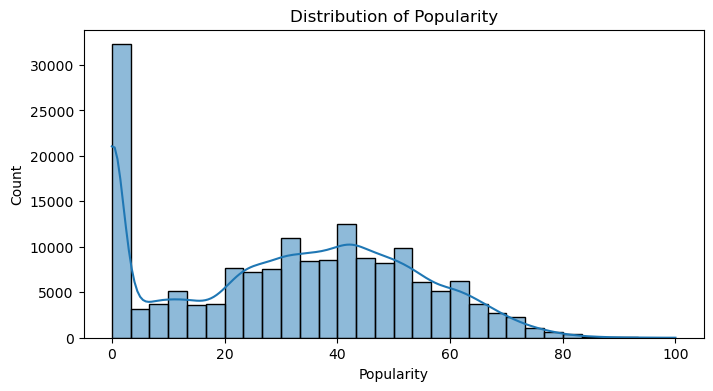

In [12]:
# 1. Distribution of target variable (popularity)

plt.figure(figsize=(8, 4))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title('Distribution of Popularity')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.show()

In [13]:
zero_pop = df[df['popularity'] == 0]
print(f"Tracks with popularity 0: {len(zero_pop)} ({len(zero_pop)/len(df)*100:.2f}%)")
zero_pop.head(10)

Tracks with popularity 0: 27357 (16.10%)


,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.995,['Carl Woitschach'],0.708,158648,0.1950,0,6KbQ3uYMLKb5jDxLF7wYDD,0.563,10,0.1510,-12.428,1,Singende Bataillone 1. Teil,0,1928,0.0506,118.469,0.7790,1928
1,0.994,"['Robert Schumann', 'Vladimir Horowitz']",0.379,282133,0.0135,0,6KuQTIu1KoTTkLXKrwlLPV,0.901,8,0.0763,-28.454,1,"Fantasiestücke, Op. 111: Più tosto lento",0,1928,0.0462,83.972,0.0767,1928
2,0.604,['Seweryn Goszczyński'],0.749,104300,0.2200,0,6L63VW0PibdM1HDSBoqnoM,0.000,5,0.1190,-19.924,0,Chapter 1.18 - Zamek kaniowski,0,1928,0.9290,107.177,0.8800,1928
3,0.995,['Francisco Canaro'],0.781,180760,0.1300,0,6M94FkXd15sOAOQYRnWPN8,0.887,1,0.1110,-14.734,0,Bebamos Juntos - Instrumental (Remasterizado),0,1928-09-25,0.0926,108.003,0.7200,1928
5,0.995,"['Felix Mendelssohn', 'Vladimir Horowitz']",0.424,352600,0.1200,0,6NxAf7M8DNHOBTmEd3JSO5,0.911,6,0.0915,-19.242,0,Scherzo a capriccio: Presto,0,1928,0.0593,63.521,0.2660,1928
6,0.956,"['Franz Liszt', 'Vladimir Horowitz']",0.444,136627,0.1970,0,6O0puPuyrxPjDTHDUgsWI7,0.435,11,0.0744,-17.226,1,"Valse oubliée No. 1 in F-Sharp Major, S. 215/1",0,1928,0.0400,80.495,0.3050,1928
7,0.988,['Carl Woitschach'],0.555,153967,0.4210,0,6OJjveoYwJdIt76y0Pxpxw,0.836,1,0.1050,-9.878,1,Per aspera ad astra,0,1928,0.0474,123.310,0.8570,1928
8,0.995,"['Francisco Canaro', 'Charlo']",0.683,162493,0.2070,0,6OaJ8Bh7lsBeYoBmwmo2nh,0.206,9,0.3370,-9.801,0,Moneda Corriente - Remasterizado,0,1928-10-03,0.1270,119.833,0.4930,1928
9,0.846,['Seweryn Goszczyński'],0.674,111600,0.2050,0,6PrZexNb16cabXR8Q418Xc,0.000,9,0.1700,-20.119,1,Chapter 1.3 - Zamek kaniowski,0,1928,0.9540,81.249,0.7590,1928
10,0.994,"['Sergei Rachmaninoff', 'Vladimir Horowitz']",0.376,590293,0.0719,0,6QBInZBkQNIQYU9gGzT5l4,0.883,10,0.1960,-21.849,0,"Piano Sonata No. 2 in B-Flat Minor, Op. 36: I....",0,1928,0.0352,141.390,0.0393,1928


In [14]:
zero_pct = (df['popularity'] == 0).sum() / len(df) * 100
print(f"Popularity = 0: {zero_pct:.2f}%")

Popularity = 0: 16.10%


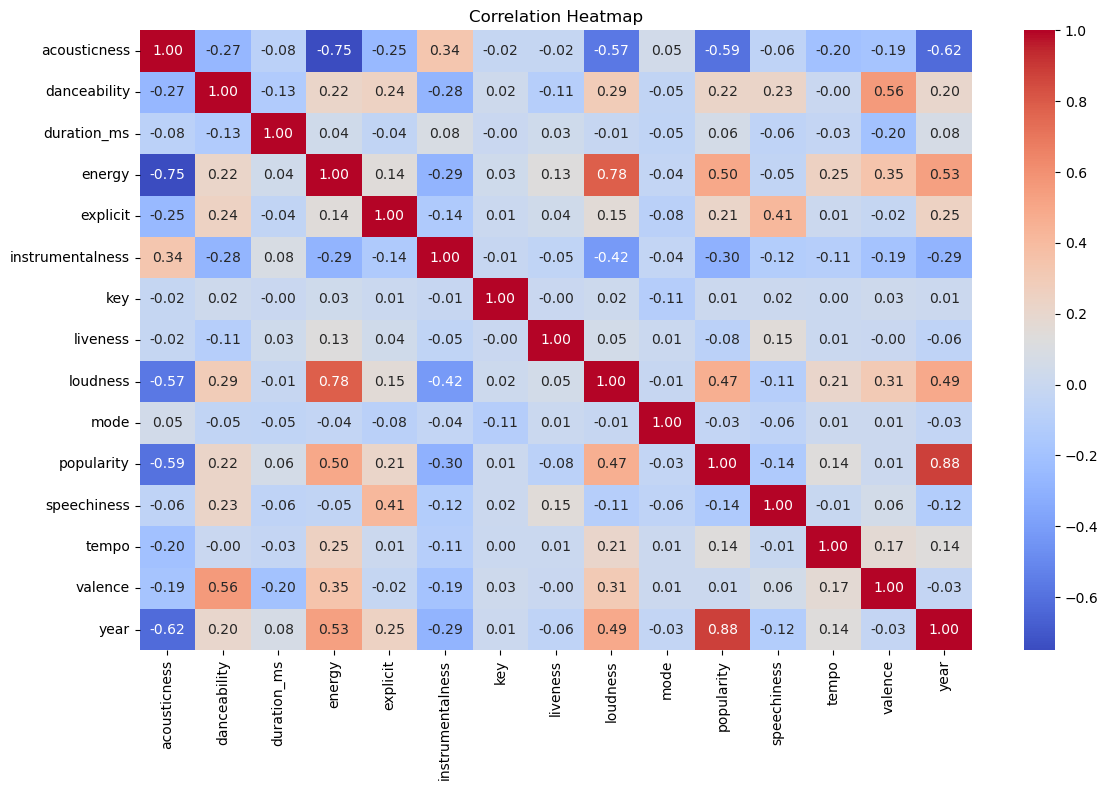

In [15]:
# 2. Correlation heatmap of all numeric features

plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

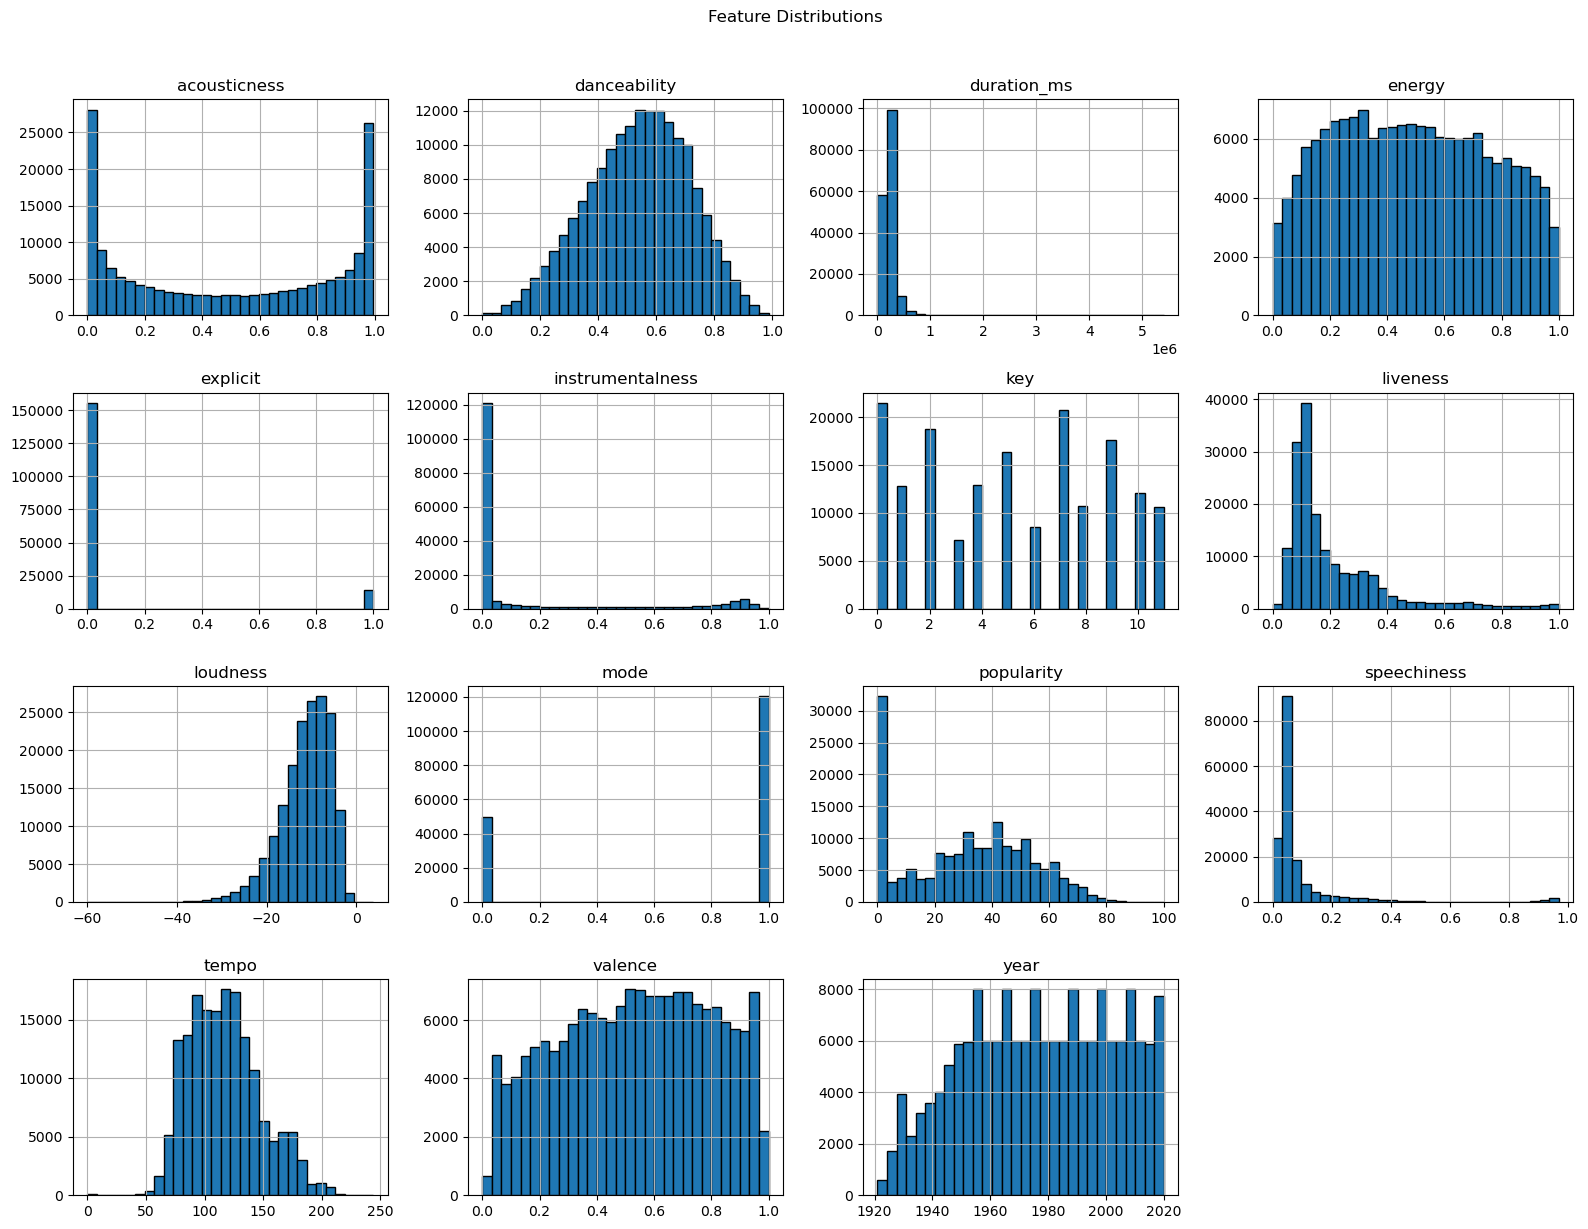

In [16]:
# 3. Feature distributions (histograms)

df.select_dtypes(include='number').hist(figsize=(16, 12), bins=30, edgecolor='black')
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

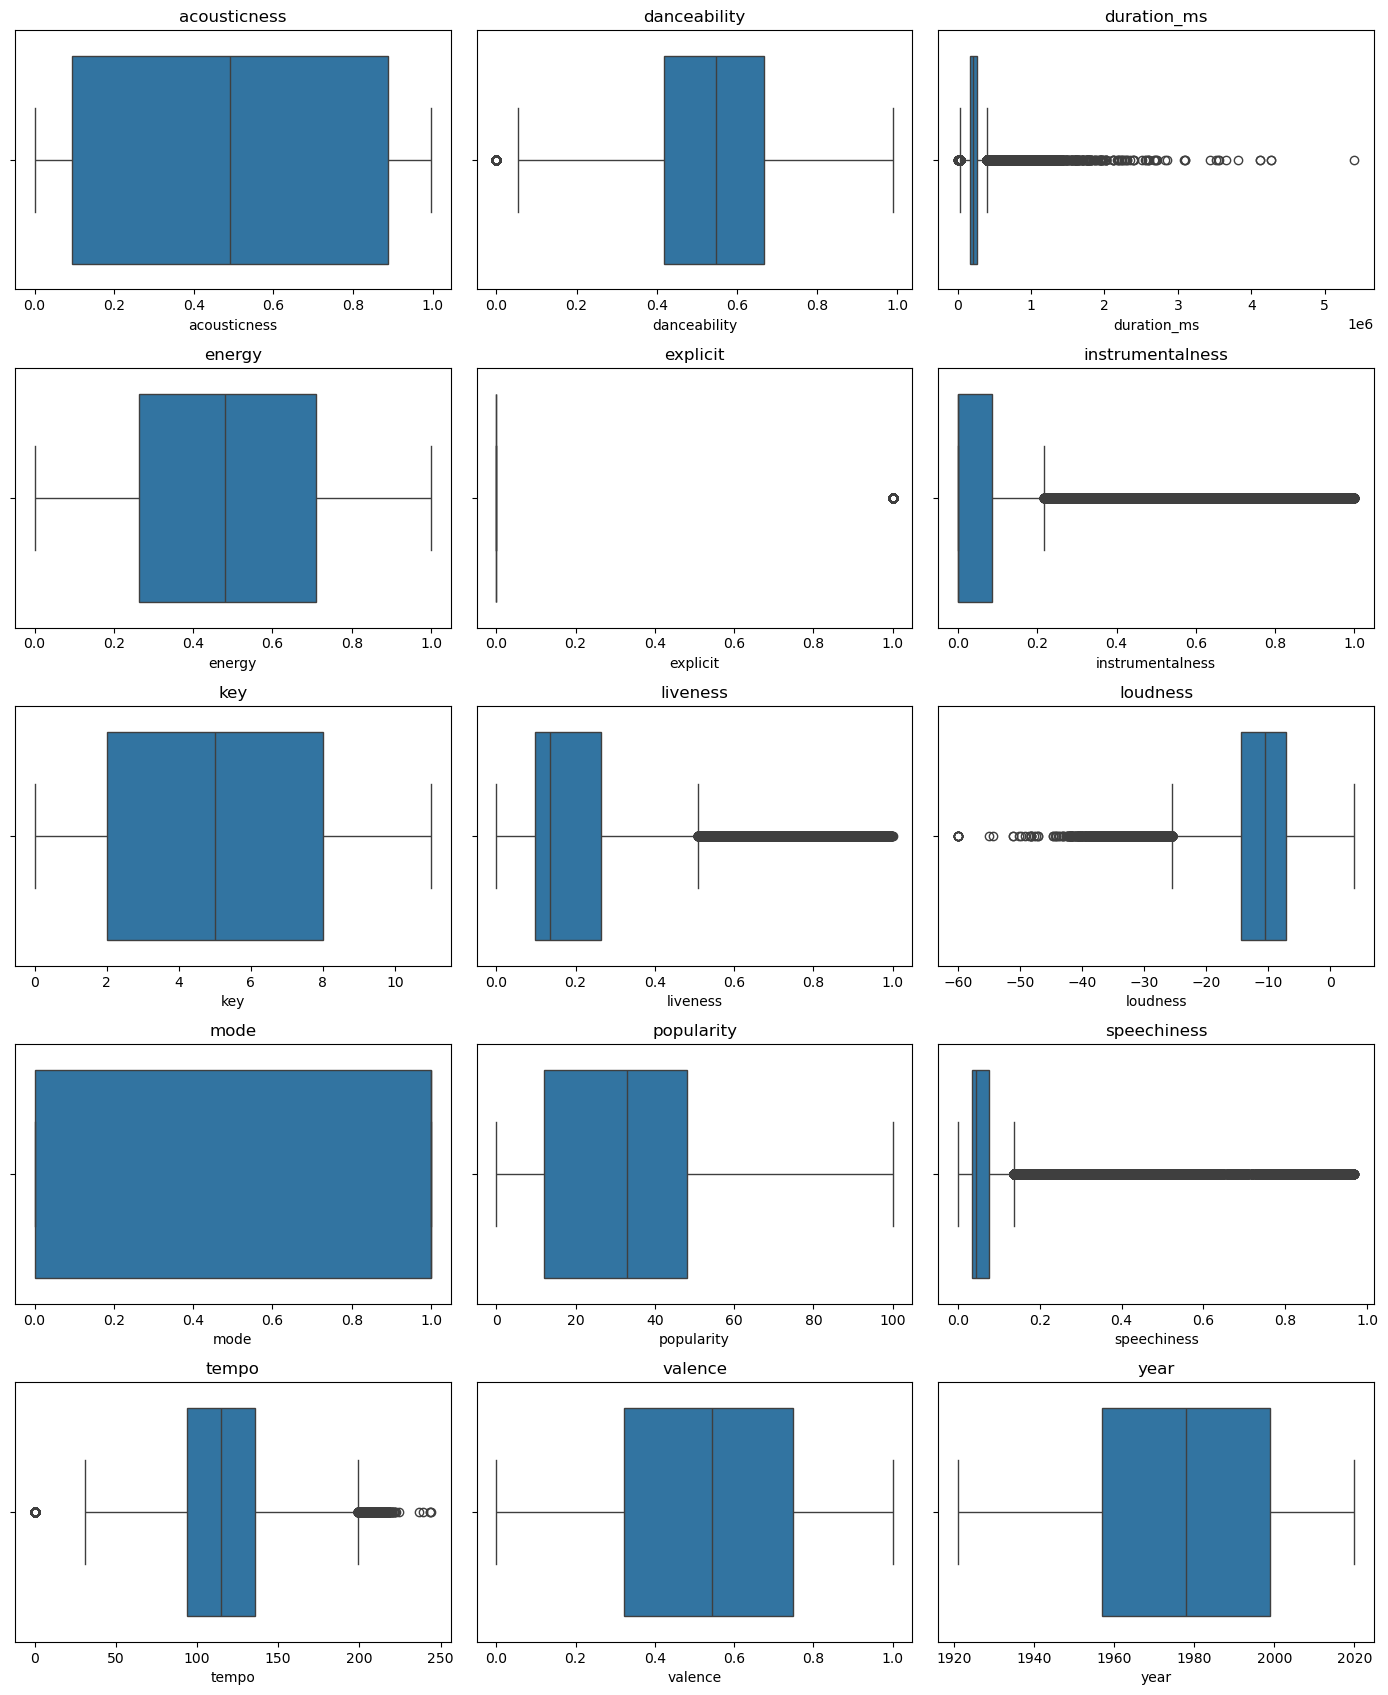

In [17]:
# 4. Outlier detection (boxplots)

numeric_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(len(numeric_cols)//3 + 1, 3, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

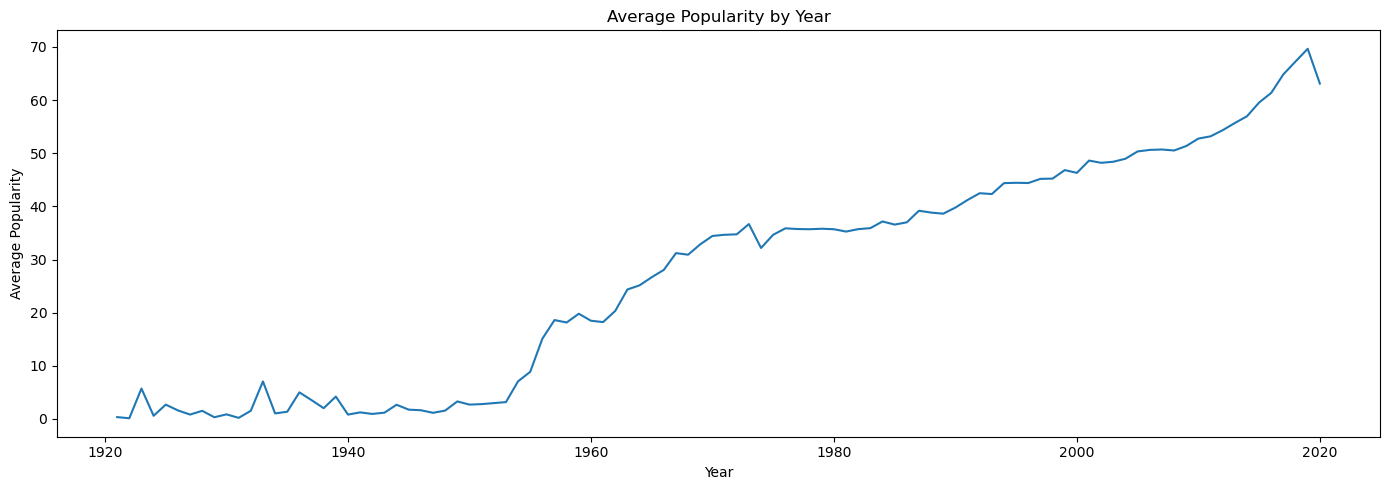

,year,avg_popularity
0,2019,69.66
1,2018,67.28
2,2017,64.86
3,2020,63.11
4,2016,61.37
5,2015,59.55
6,2014,56.96
7,2013,55.69
8,2012,54.34
9,2011,53.18


In [18]:
# 5. Year-wise popularity analysis

plt.figure(figsize=(14, 5))
df.groupby('year')['popularity'].mean().plot()
plt.title('Average Popularity by Year')
plt.xlabel('Year')
plt.ylabel('Average Popularity')
plt.tight_layout()
plt.show()

df.groupby('year')['popularity'].mean().sort_values(ascending=False).round(2).reset_index().rename(columns={'popularity': 'avg_popularity'}).head(20)

## 4. Data Preparation

1. Feature engineering
2. Target specification
3. Train-Test split

## 4.1 Feature Engineering

### Feature Strategy
| Feature | Type | Encoding |
|---|---|---|
| acousticness, danceability, energy, instrumentalness, liveness, loudness, speechiness, tempo, valence, duration_ms, year | Numeric | Keep as-is |
| `key` | Categorical (12 musical keys: C, C#, D…) | One-hot encode |
| `mode` | Binary categorical (0 = minor, 1 = major) | Keep as-is |
| `explicit` | Binary categorical (0 = no, 1 = yes) | Keep as-is |
| id, name, artists, release_date | Identity / free text | Drop |

In [19]:
# Drop duplicate ids, keep first occurrence
df = df.drop_duplicates(subset=['id'])
print(f"Shape after deduplication: {df.shape}")

Shape after deduplication: (169909, 19)


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169909 entries, 0 to 169908
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   acousticness      169909 non-null  float64
 1   artists           169909 non-null  object 
 2   danceability      169909 non-null  float64
 3   duration_ms       169909 non-null  int64  
 4   energy            169909 non-null  float64
 5   explicit          169909 non-null  int64  
 6   id                169909 non-null  object 
 7   instrumentalness  169909 non-null  float64
 8   key               169909 non-null  int64  
 9   liveness          169909 non-null  float64
 10  loudness          169909 non-null  float64
 11  mode              169909 non-null  int64  
 12  name              169909 non-null  object 
 13  popularity        169909 non-null  int64  
 14  release_date      169909 non-null  object 
 15  speechiness       169909 non-null  float64
 16  tempo             16

In [21]:
# Columns to drop — identity/reference only, not model inputs
drop_cols = ['id', 'name', 'artists', 'release_date']

df_model = df.drop(columns=drop_cols).copy()

print("Columns kept for modelling:")
for col in df_model.columns:
    print(f"  {col} ({df_model[col].dtype})")

Columns kept for modelling:
  acousticness (float64)
  danceability (float64)
  duration_ms (int64)
  energy (float64)
  explicit (int64)
  instrumentalness (float64)
  key (int64)
  liveness (float64)
  loudness (float64)
  mode (int64)
  popularity (int64)
  speechiness (float64)
  tempo (float64)
  valence (float64)
  year (int64)


In [22]:
# One-hot encode key (0=C, 1=C#, ... 11=B)
# drop_first=True drops key_0 to avoid multicollinearity
key_dummies = pd.get_dummies(df_model['key'], prefix='key', drop_first=True)
df_model = pd.concat([df_model.drop(columns=['key']), key_dummies], axis=1)
print(f"Key columns after one-hot encoding: {[c for c in df_model.columns if c.startswith('key_')]}")

# Encode explicit as int (True -> 1, False -> 0)
df_model['explicit'] = df_model['explicit'].astype(int)

print(f"\nDataset shape after encoding: {df_model.shape}")

Key columns after one-hot encoding: ['key_1', 'key_2', 'key_3', 'key_4', 'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10', 'key_11']

Dataset shape after encoding: (169909, 25)


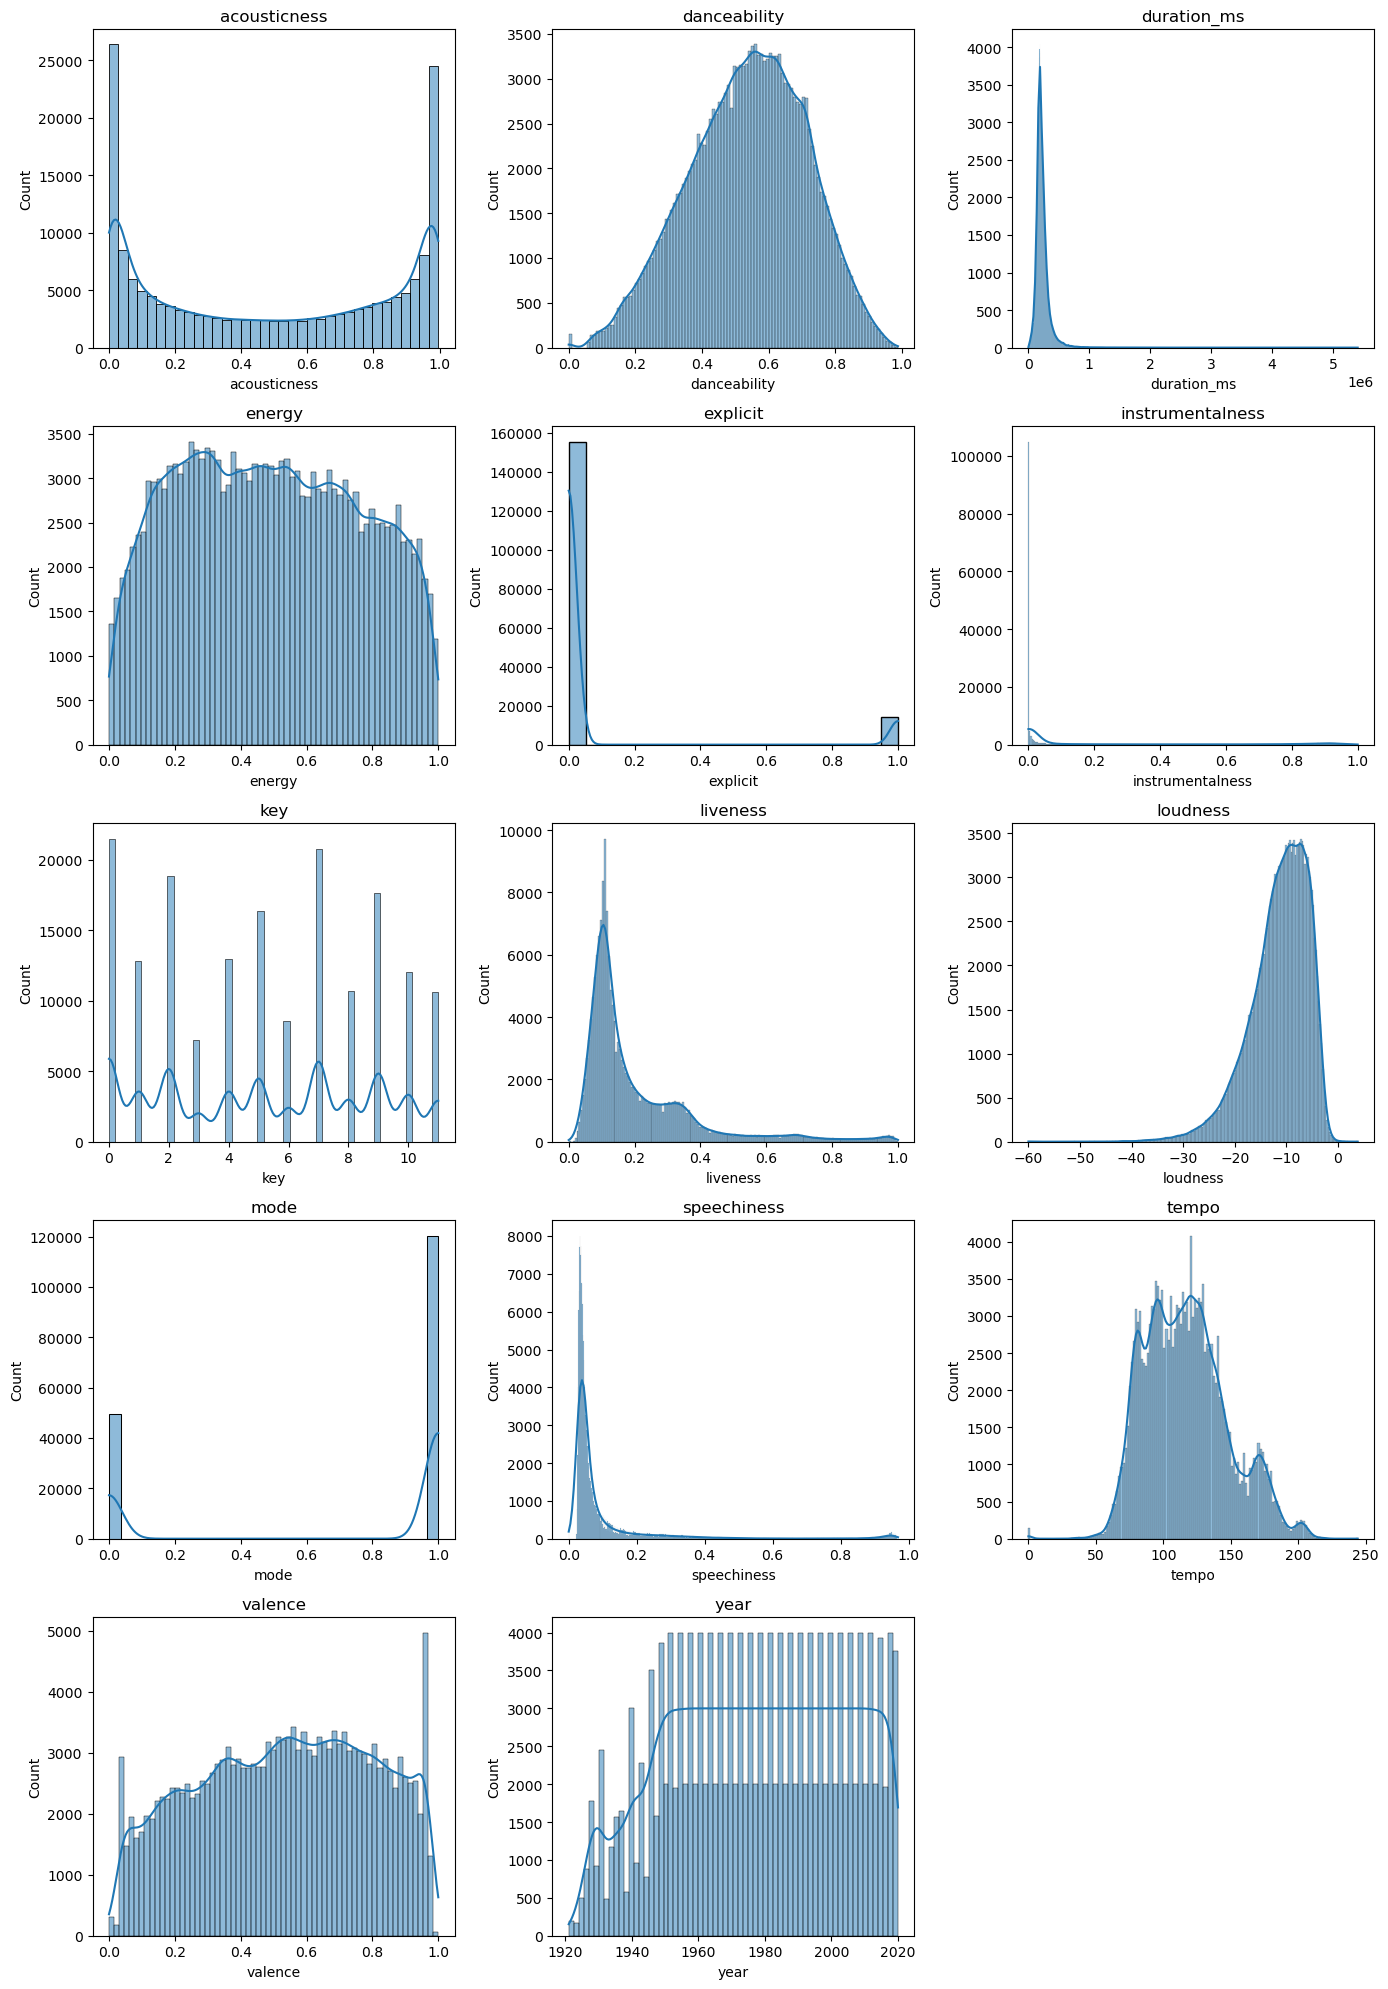

In [23]:
numeric_cols = df.select_dtypes(include='number').columns.drop('popularity')

fig, axes = plt.subplots(len(numeric_cols)//3 + 1, 3, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [24]:
X = df_model.drop(columns=['popularity'])
y = df_model['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (135927, 24), Test: (33982, 24)


In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
comparison = pd.DataFrame({
    'before_mean': X_train.mean(),
    'after_mean': pd.DataFrame(X_train_scaled, columns=X_train.columns).mean(),
    'before_std': X_train.std(),
    'after_std': pd.DataFrame(X_train_scaled, columns=X_train.columns).std()
})
comparison.round(4)

,before_mean,after_mean,before_std,after_std
acousticness,0.4932,0.0,0.3767,1.0
danceability,0.5381,0.0,0.1754,1.0
duration_ms,231399.2434,0.0,122161.3079,1.0
energy,0.4884,0.0,0.2672,1.0
explicit,0.0847,-0.0,0.2784,1.0
instrumentalness,0.1618,0.0,0.3093,1.0
liveness,0.2064,0.0,0.1768,1.0
loudness,-11.3696,-0.0,5.6582,1.0
mode,0.7080,0.0,0.4547,1.0
speechiness,0.0939,-0.0,0.1497,1.0


Skewness: -0.02


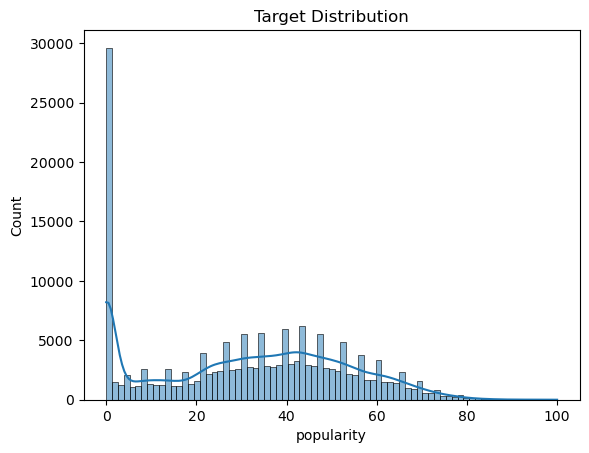

In [27]:
print(f"Skewness: {y.skew():.2f}")
sns.histplot(y, kde=True)
plt.title('Target Distribution')
plt.show()

## 5. Modeling

In [28]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"MSE:  {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

R²:   0.7820
MSE:  101.7754
RMSE: 10.0884


In [29]:
X_train.to_csv('X_train_data2.csv', index=False)
X_test.to_csv('X_test_data2.csv', index=False)
y_train.to_csv('y_train_data2.csv', index=False)
y_test.to_csv('y_test_data2.csv', index=False)